# Day 2 — Pandas, Dates and Data Cleaning

## Goal

Today I am learning how to work with a financial time-series dataset
using Pandas.

Topics:
- Dates and DatetimeIndex
- Selecting rows and columns
- .loc and .iloc
- Boolean filtering
- Sorting
- Missing values
- Duplicate rows
- Saving and loading CSV data

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
ticker = yf.Ticker("AAPL")

data = ticker.history(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d",
    prepost=False,
    auto_adjust=False
)

data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0


In [7]:
data.index

DatetimeIndex(['2015-01-02 00:00:00-05:00', '2015-01-05 00:00:00-05:00',
               '2015-01-06 00:00:00-05:00', '2015-01-07 00:00:00-05:00',
               '2015-01-08 00:00:00-05:00', '2015-01-09 00:00:00-05:00',
               '2015-01-12 00:00:00-05:00', '2015-01-13 00:00:00-05:00',
               '2015-01-14 00:00:00-05:00', '2015-01-15 00:00:00-05:00',
               ...
               '2025-12-17 00:00:00-05:00', '2025-12-18 00:00:00-05:00',
               '2025-12-19 00:00:00-05:00', '2025-12-22 00:00:00-05:00',
               '2025-12-23 00:00:00-05:00', '2025-12-24 00:00:00-05:00',
               '2025-12-26 00:00:00-05:00', '2025-12-29 00:00:00-05:00',
               '2025-12-30 00:00:00-05:00', '2025-12-31 00:00:00-05:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=2766, freq=None)

In [11]:
data.iloc[:5]

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0


In [12]:
data.loc["2020-01-02"]

Open            7.406000e+01
High            7.515000e+01
Low             7.379750e+01
Close           7.508750e+01
Adj Close       7.227155e+01
Volume          1.354804e+08
Dividends       0.000000e+00
Stock Splits    0.000000e+00
Name: 2020-01-02 00:00:00-05:00, dtype: float64

In [14]:
data["Close"]

Date
2015-01-02 00:00:00-05:00     27.332500
2015-01-05 00:00:00-05:00     26.562500
2015-01-06 00:00:00-05:00     26.565001
2015-01-07 00:00:00-05:00     26.937500
2015-01-08 00:00:00-05:00     27.972500
                                ...    
2025-12-24 00:00:00-05:00    273.809998
2025-12-26 00:00:00-05:00    273.399994
2025-12-29 00:00:00-05:00    273.760010
2025-12-30 00:00:00-05:00    273.079987
2025-12-31 00:00:00-05:00    271.859985
Name: Close, Length: 2766, dtype: float64

In [18]:
data.loc[
    "2020-01-01":"2020-12-31",
    ["Open", "High", "Low", "Close"]
]


,Open,High,Low,Close
Date,,,,
2020-01-02 00:00:00-05:00,74.059998,75.150002,73.797501,75.087502
2020-01-03 00:00:00-05:00,74.287498,75.144997,74.125000,74.357498
2020-01-06 00:00:00-05:00,73.447502,74.989998,73.187500,74.949997
2020-01-07 00:00:00-05:00,74.959999,75.224998,74.370003,74.597504
2020-01-08 00:00:00-05:00,74.290001,76.110001,74.290001,75.797501
...,...,...,...,...
2020-12-24 00:00:00-05:00,131.320007,133.460007,131.100006,131.970001
2020-12-28 00:00:00-05:00,133.990005,137.339996,133.509995,136.690002
2020-12-29 00:00:00-05:00,138.050003,138.789993,134.339996,134.869995


In [30]:
high_price_days = data[data["Close"] > 280]
high_price_days.head()
#high_price_days.count()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-12-01 00:00:00-05:00,278.010010,283.420013,276.140015,283.100006,282.331482,46587700,0.0,0.0
2025-12-02 00:00:00-05:00,283.000000,287.399994,282.630005,286.190002,285.413116,53669500,0.0,0.0
2025-12-03 00:00:00-05:00,286.200012,288.619995,283.299988,284.149994,283.378662,43538700,0.0,0.0
2025-12-04 00:00:00-05:00,284.100006,284.730011,278.589996,280.700012,279.938049,43989100,0.0,0.0


In [34]:
high_price_days = data.loc[data["Close"] > 280]
high_price_days.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-12-01 00:00:00-05:00,278.010010,283.420013,276.140015,283.100006,282.331482,46587700,0.0,0.0
2025-12-02 00:00:00-05:00,283.000000,287.399994,282.630005,286.190002,285.413116,53669500,0.0,0.0
2025-12-03 00:00:00-05:00,286.200012,288.619995,283.299988,284.149994,283.378662,43538700,0.0,0.0
2025-12-04 00:00:00-05:00,284.100006,284.730011,278.589996,280.700012,279.938049,43989100,0.0,0.0


In [39]:
filtered = data.loc[
    (data["Close"] > 280) &
    (data["Volume"] > 40_000_000)
]

filtered.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-12-01 00:00:00-05:00,278.010010,283.420013,276.140015,283.100006,282.331482,46587700,0.0,0.0
2025-12-02 00:00:00-05:00,283.000000,287.399994,282.630005,286.190002,285.413116,53669500,0.0,0.0
2025-12-03 00:00:00-05:00,286.200012,288.619995,283.299988,284.149994,283.378662,43538700,0.0,0.0
2025-12-04 00:00:00-05:00,284.100006,284.730011,278.589996,280.700012,279.938049,43989100,0.0,0.0


In [40]:
data_2024 = data.loc["2024"]

In [41]:
data_2024.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2024-01-02 00:00:00-05:00,187.149994,188.440002,183.889999,185.639999,183.404007,82488700,0.0,0.0
2024-01-03 00:00:00-05:00,184.220001,185.880005,183.429993,184.250000,182.030762,58414500,0.0,0.0
2024-01-04 00:00:00-05:00,182.149994,183.089996,180.880005,181.910004,179.718948,71983600,0.0,0.0
2024-01-05 00:00:00-05:00,181.990005,182.759995,180.169998,181.179993,178.997742,62379700,0.0,0.0
2024-01-08 00:00:00-05:00,182.089996,185.600006,181.500000,185.559998,183.324982,59144500,0.0,0.0


In [44]:
data_q1_2024 = data.loc["2024-01-01":"2024-03-31"]

data_q1_2024.head

<bound method NDFrame.head of                                  Open        High         Low       Close  \
Date                                                                        
2024-01-02 00:00:00-05:00  187.149994  188.440002  183.889999  185.639999   
2024-01-03 00:00:00-05:00  184.220001  185.880005  183.429993  184.250000   
2024-01-04 00:00:00-05:00  182.149994  183.089996  180.880005  181.910004   
2024-01-05 00:00:00-05:00  181.990005  182.759995  180.169998  181.179993   
2024-01-08 00:00:00-05:00  182.089996  185.600006  181.500000  185.559998   
...                               ...         ...         ...         ...   
2024-03-22 00:00:00-04:00  171.759995  173.050003  170.059998  172.279999   
2024-03-25 00:00:00-04:00  170.570007  171.940002  169.449997  170.850006   
2024-03-26 00:00:00-04:00  170.000000  171.419998  169.580002  169.710007   
2024-03-27 00:00:00-04:00  170.410004  173.600006  170.110001  173.309998   
2024-03-28 00:00:00-04:00  171.750000  172.229

In [54]:
data.sort_index(ascending=False).head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-12-31 00:00:00-05:00,273.059998,273.679993,271.750000,271.859985,271.122009,27293600,0.0,0.0
2025-12-30 00:00:00-05:00,272.809998,274.079987,272.279999,273.079987,272.338684,22139600,0.0,0.0
2025-12-29 00:00:00-05:00,272.690002,274.359985,272.350006,273.760010,273.016876,23715200,0.0,0.0
2025-12-26 00:00:00-05:00,274.160004,275.369995,272.859985,273.399994,272.657837,21521800,0.0,0.0
2025-12-24 00:00:00-05:00,272.339996,275.429993,272.200012,273.809998,273.066711,17910600,0.0,0.0


In [55]:
data = data.sort_index()

In [57]:
data.sort_values("Close", ascending=False).head(10)

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-12-02 00:00:00-05:00,283.000000,287.399994,282.630005,286.190002,285.413116,53669500,0.0,0.0
2025-12-03 00:00:00-05:00,286.200012,288.619995,283.299988,284.149994,283.378662,43538700,0.0,0.0
2025-12-01 00:00:00-05:00,278.010010,283.420013,276.140015,283.100006,282.331482,46587700,0.0,0.0
2025-12-04 00:00:00-05:00,284.100006,284.730011,278.589996,280.700012,279.938049,43989100,0.0,0.0
2025-11-28 00:00:00-05:00,277.260010,279.000000,275.989990,278.850006,278.093048,20135600,0.0,0.0
2025-12-05 00:00:00-05:00,280.540009,281.140015,278.049988,278.779999,278.023224,47265800,0.0,0.0
2025-12-10 00:00:00-05:00,277.750000,279.750000,276.440002,278.779999,278.023224,33038300,0.0,0.0
2025-12-12 00:00:00-05:00,277.899994,279.220001,276.820007,278.279999,277.524597,39532900,0.0,0.0
2025-12-11 00:00:00-05:00,279.100006,279.589996,273.809998,278.029999,277.275238,33248000,0.0,0.0


In [128]:
data.loc["2024-01-01":"2025-01-01"].sort_values("Volume", ascending=False)

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2024-09-20 00:00:00-04:00,229.970001,233.089996,227.619995,228.199997,226.306885,318679900,0.0,0.0,-0.002928
2024-06-21 00:00:00-04:00,210.389999,211.889999,207.110001,207.490005,205.530792,241805100,0.0,0.0,-0.010445
2024-06-12 00:00:00-04:00,207.369995,220.199997,206.899994,213.070007,211.058105,198134300,0.0,0.0,0.028578
2024-06-11 00:00:00-04:00,193.649994,207.160004,193.630005,207.149994,205.194016,172373300,0.0,0.0,0.072649
2024-05-03 00:00:00-04:00,186.649994,187.000000,182.660004,183.380005,181.402420,163224100,0.0,0.0,0.059816
...,...,...,...,...,...,...,...,...,...
2024-11-29 00:00:00-05:00,234.809998,237.809998,233.970001,237.330002,235.620117,28481400,0.0,0.0,0.010216
2024-10-10 00:00:00-04:00,227.779999,229.500000,227.169998,229.039993,227.139938,28183500,0.0,0.0,-0.002178
2024-11-05 00:00:00-05:00,221.800003,223.949997,221.139999,223.449997,221.596298,28111300,0.0,0.0,0.006486


In [130]:
data.nlargest(10, "Volume")[
    ["Close", "Volume"]
]

,Close,Volume
Date,,
2015-08-24 00:00:00-04:00,25.780001,648825200
2015-01-28 00:00:00-05:00,28.827499,585908400
2016-01-27 00:00:00-05:00,23.355000,533478800
2015-08-21 00:00:00-04:00,26.440001,513102000
2015-08-04 00:00:00-04:00,28.660000,496554400
2015-04-28 00:00:00-04:00,32.639999,475696000
2015-07-22 00:00:00-04:00,31.305000,461802400
2016-04-27 00:00:00-04:00,24.455000,458408400
2017-02-01 00:00:00-05:00,32.187500,447940000


In [76]:
data["daily_return"] = data["Adj Close"].pct_change()
data["daily_return"].head()

Date
2015-01-02 00:00:00-05:00         NaN
2015-01-05 00:00:00-05:00   -0.028172
2015-01-06 00:00:00-05:00    0.000094
2015-01-07 00:00:00-05:00    0.014022
2015-01-08 00:00:00-05:00    0.038423
Name: daily_return, dtype: float64

In [77]:
data.isna().sum()

Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
daily_return    1
dtype: int64

In [78]:
data.isna().any()

Open            False
High            False
Low             False
Close           False
Adj Close       False
Volume          False
Dividends       False
Stock Splits    False
daily_return     True
dtype: bool

In [ ]:
data.index.duplicated().sum()

np.int64(0)

In [81]:
data.index.is_monotonic_increasing

True

In [82]:
clean_data = data.copy()

In [83]:
clean_data = clean_data.dropna(
    subset=["daily_return"]
)

In [84]:
clean_data["daily_return"].isna().sum()

np.int64(0)

In [90]:
clean_data["daily_return"].head()

Date
2015-01-05 00:00:00-05:00   -0.028172
2015-01-06 00:00:00-05:00    0.000094
2015-01-07 00:00:00-05:00    0.014022
2015-01-08 00:00:00-05:00    0.038423
2015-01-09 00:00:00-05:00    0.001072
Name: daily_return, dtype: float64

In [91]:
raw_path = "../data/raw/AAPL_daily_raw.csv"

data.to_csv(raw_path)

print(f"Saved raw data to: {raw_path}")

Saved raw data to: ../data/raw/AAPL_daily_raw.csv


In [92]:
loaded_data = pd.read_csv(
    raw_path,
    index_col="Date",
    parse_dates=True
)

In [93]:
loaded_data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0,NaN
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0,-0.028172
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0,0.000094
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0,0.014022
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0,0.038423


In [99]:
loaded_data.info()

<class 'pandas.DataFrame'>
Index: 2766 entries, 2015-01-02 00:00:00-05:00 to 2025-12-31 00:00:00-05:00
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2766 non-null   float64
 1   High          2766 non-null   float64
 2   Low           2766 non-null   float64
 3   Close         2766 non-null   float64
 4   Adj Close     2766 non-null   float64
 5   Volume        2766 non-null   int64  
 6   Dividends     2766 non-null   float64
 7   Stock Splits  2766 non-null   float64
 8   daily_return  2765 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 216.1+ KB


In [107]:
type(loaded_data.index)

pandas.Index

In [108]:
loaded_data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0,NaN
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0,-0.028172
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0,0.000094
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0,0.014022
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0,0.038423


In [110]:
loaded_data.index = pd.to_datetime(loaded_data.index, utc=True)

In [111]:
type(loaded_data.index)

pandas.DatetimeIndex

In [112]:
loaded_data.loc["2024"]

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2024-01-02 05:00:00+00:00,187.149994,188.440002,183.889999,185.639999,183.404007,82488700,0.0,0.0,-0.035787
2024-01-03 05:00:00+00:00,184.220001,185.880005,183.429993,184.250000,182.030762,58414500,0.0,0.0,-0.007488
2024-01-04 05:00:00+00:00,182.149994,183.089996,180.880005,181.910004,179.718948,71983600,0.0,0.0,-0.012700
2024-01-05 05:00:00+00:00,181.990005,182.759995,180.169998,181.179993,178.997742,62379700,0.0,0.0,-0.004013
2024-01-08 05:00:00+00:00,182.089996,185.600006,181.500000,185.559998,183.324982,59144500,0.0,0.0,0.024175
...,...,...,...,...,...,...,...,...,...
2024-12-24 05:00:00+00:00,255.490005,258.209991,255.289993,258.200012,256.339783,23234700,0.0,0.0,0.011478
2024-12-26 05:00:00+00:00,258.190002,260.100006,257.630005,259.019989,257.153778,27237100,0.0,0.0,0.003175
2024-12-27 05:00:00+00:00,257.829987,258.700012,253.059998,255.589996,253.748520,42355300,0.0,0.0,-0.013242


In [115]:
aapl_2024 = clean_data.loc["2024"].copy()

In [117]:
aapl_2024["daily_return"].mean()
aapl_2024["daily_return"].std()

np.float64(0.014287357221957191)

In [120]:
aapl_2024.nlargest(5, "Volume")[
    ["Open", "High", "Low", "Close", "Volume"]
]

,Open,High,Low,Close,Volume
Date,,,,,
2024-09-20 00:00:00-04:00,229.970001,233.089996,227.619995,228.199997,318679900
2024-06-21 00:00:00-04:00,210.389999,211.889999,207.110001,207.490005,241805100
2024-06-12 00:00:00-04:00,207.369995,220.199997,206.899994,213.070007,198134300
2024-06-11 00:00:00-04:00,193.649994,207.160004,193.630005,207.149994,172373300
2024-05-03 00:00:00-04:00,186.649994,187.000000,182.660004,183.380005,163224100


In [121]:
aapl_2024.nsmallest(5, "daily_return")[
    ["Close", "Volume", "daily_return"]
]

,Close,Volume,daily_return
Date,,,
2024-08-05 00:00:00-04:00,209.270004,119548600,-0.048167
2024-03-21 00:00:00-04:00,171.369995,106181300,-0.040858
2024-01-02 00:00:00-05:00,185.639999,82488700,-0.035787
2024-10-01 00:00:00-04:00,226.210007,63285000,-0.029142
2024-07-24 00:00:00-04:00,218.539993,61777600,-0.028754


In [123]:
aapl_2024["percentage"] = (aapl_2024["daily_return"] * 100).round(2).astype(str) + "%"
aapl_2024.nsmallest(5, "daily_return")[
    ["Close", "Volume", "daily_return", "percentage"]
]

,Close,Volume,daily_return,percentage
Date,,,,
2024-08-05 00:00:00-04:00,209.270004,119548600,-0.048167,-4.82%
2024-03-21 00:00:00-04:00,171.369995,106181300,-0.040858,-4.09%
2024-01-02 00:00:00-05:00,185.639999,82488700,-0.035787,-3.58%
2024-10-01 00:00:00-04:00,226.210007,63285000,-0.029142,-2.91%
2024-07-24 00:00:00-04:00,218.539993,61777600,-0.028754,-2.88%


In [127]:
aapl_2024["percentage"] = (aapl_2024["daily_return"] * 100).round(2).astype(str) + "%"
aapl_2024.nlargest(5, "daily_return")[["Close", "Volume", "daily_return", "percentage"]]

,Close,Volume,daily_return,percentage
Date,,,,
2024-06-11 00:00:00-04:00,207.149994,172373300,0.072649,7.26%
2024-05-03 00:00:00-04:00,183.380005,163224100,0.059816,5.98%
2024-04-11 00:00:00-04:00,175.039993,91070300,0.043271,4.33%
2024-09-19 00:00:00-04:00,228.869995,66781300,0.037066,3.71%
2024-01-18 00:00:00-05:00,188.630005,78005800,0.032571,3.26%


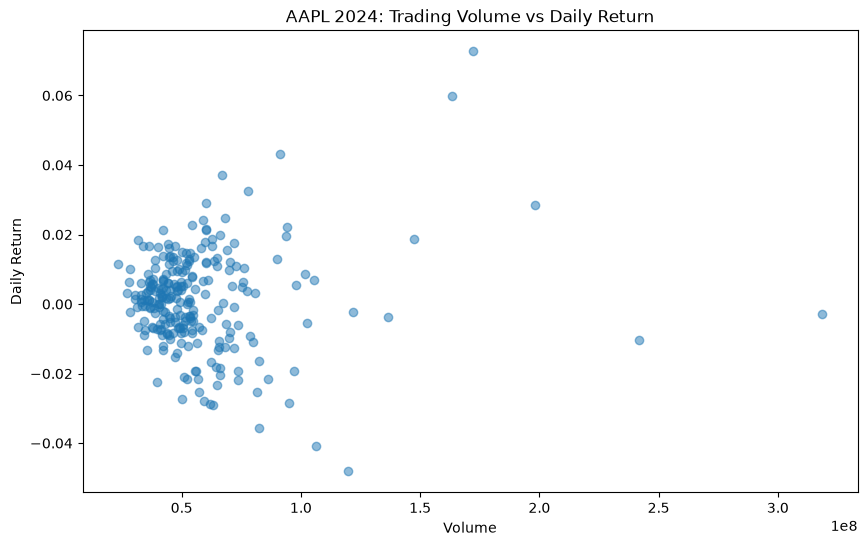

In [131]:
plt.figure(figsize=(10, 6))

plt.scatter(
    aapl_2024["Volume"],
    aapl_2024["daily_return"],
    alpha=0.5
)

plt.title("AAPL 2024: Trading Volume vs Daily Return")
plt.xlabel("Volume")
plt.ylabel("Daily Return")

plt.show()